# Level 4 — Data Cleaning, Scientific Data Analysis, and Visualization

## Overview

In the previous levels we built the mathematical and computational engine
of HydroSense-Kenya. We wrote functions, implemented numerical methods,
and performed calculations — but we were working with raw data that still
contains missing values, outliers, sensor faults, and inconsistencies.

In a real scientific computing system, the quality of your results is
only as good as the quality of your data. Garbage in, garbage out.
This level addresses that directly.

Level 4 has two main objectives:

**Objective 1 — Data Cleaning**
Transform the three raw datasets into a single clean, reliable dataset
that can be trusted for computation. Every cleaning decision must be
documented and scientifically justified — not just "I removed this value"
but "I removed this value because it is physically impossible given the
sensor specifications and the surrounding readings."

**Objective 2 — Scientific Visualization and Analysis**
Produce at least five scientific visualizations that extract meaningful
insight from the cleaned data. Each visualization must be interpreted
scientifically — not just describing what the graph looks like, but
explaining what it means for irrigation decisions.

## What This Level Covers

1. Loading all three datasets using Pandas
2. Identifying missing values, outliers, sensor faults, and inconsistencies
3. Cleaning the dataset and documenting every decision
4. Computing descriptive statistics for key variables
5. Creating at least five scientific visualizations
6. Interpreting each visualization using scientific reasoning

## Important Note

The cleaned dataset produced at the end of this level —
cleaned_irrigation_dataset.csv — becomes the primary input for
Level 5 simulation and optimization. The quality of the cleaning
done here directly affects the reliability of every prediction
and recommendation made in Level 5.

## Task 1 and Task 2 — Loading and Inspecting the Datasets

Before we can clean the data we need to load all three datasets and
carefully inspect them to identify every problem that needs to be fixed.

We are looking for four categories of problems:

**Missing Values**
Columns where sensors failed to record a reading and left a blank
or NA value. These must be handled before any computation can proceed.

**Outliers**
Values that are so far outside the expected range that they are
almost certainly incorrect. For example a temperature of 45.8°C
in Kenya in March, or a rainfall of 85mm in a single day.

**Sensor Faults**
Readings that are technically present but physically impossible or
flagged by the sensor itself. For example a tank level of 9900 litres
when the tank capacity is clearly around 4000-5000 litres, or a pump
flow of 0.0 with a CHECK status flag.

**Inconsistencies**
Values that are individually plausible but inconsistent with
surrounding readings or with other variables on the same day.

In [1]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [7]:
#importing the datasets
weather = pd.read_csv("../data/raw/weather_daily.csv",na_values=["NA",""])
soil = pd.read_csv("../data/raw/soil_sensor_data.csv",na_values=["NA",""])
params = pd.read_csv("../data/raw/crop_zone_parameters.csv",na_values=["NA",""])

print("\n Weather Dataset : \n")
print(weather.info(),"\n")
print(weather.head(),"\n")
print(weather.describe(),"\n")
print("checking total null values : ")
print(weather.isnull().sum())

#from the outputs , rainfall_mm and humidity_pct have one NaN value each.
#datetime format = date

print("\nSoil Sensor Dataset: \n")
print(soil.info(),"\n")
print(soil.head(),"\n")
print(soil.describe(),"\n")

print("checking for non values : \n")
print(soil.isnull().sum())

#soil_moisture_pct has one null value.
#date time format = timestamp.

print("\n Crop Zone Parameters Dataset : \n")
print(params.info(),"\n")
print(params.head(),"\n")
print(params.describe(),"\n")
print("checking for null values in crop zone parameters : \n")
print(params.isnull().sum())

#has no null values and not datetime column.

#converting  timestamp and date to a proper date time format.
weather["date"] = pd.to_datetime(weather["date"])
soil["timestamp"] = pd.to_datetime(soil['timestamp'])

print("Rows with sensor CHECK status:\n")
print(soil[soil['sensor_status'] == 'CHECK'])



 Weather Dataset : 

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            30 non-null     str    
 1   rainfall_mm     29 non-null     float64
 2   temperature_c   30 non-null     float64
 3   humidity_pct    29 non-null     float64
 4   wind_speed_mps  30 non-null     float64
 5   solar_index     30 non-null     float64
dtypes: float64(5), str(1)
memory usage: 1.5 KB
None 

         date  rainfall_mm  temperature_c  humidity_pct  wind_speed_mps  \
0  2026-03-01          3.2           23.8          69.7            2.28   
1  2026-03-02          2.2           25.9          62.0            1.62   
2  2026-03-03          3.0           26.8          64.4            2.11   
3  2026-03-04          1.6           27.0          64.6            2.09   
4  2026-03-05         23.7           26.6          61.0            1.36   

   solar_index  
0   

## Task 3 — Data Cleaning

### Identified Problems and Cleaning Decisions

Before cleaning, we document every problem found during inspection and
the decision made for each one. This is a critical part of scientific
computing — every modification to the raw data must be justified.

#### Weather Dataset Problems

| Column | Day | Raw Value | Problem | Decision | Reason |
|--------|-----|-----------|---------|----------|--------|
| rainfall_mm | Day 8 | NA | Missing value | Fill with median | Median is more robust than mean for rainfall since heavy rain days skew the mean upward |
| humidity_pct | Day 21 | NA | Missing value | Fill with mean | Humidity is normally distributed so the mean is an appropriate estimate |
| temperature_c | Day 14 | 45.8°C | Outlier | Replace with mean | Physically impossible for Kenya in March. Normal range is 21-27°C. Clear sensor fault |
| rainfall_mm | Day 26 | 85mm | Extreme outlier | Replace with median | An 85mm single day rainfall event is extremely unlikely. Surrounding days show 0-3mm. Likely sensor error |

#### Soil Sensor Dataset Problems

| Column | Zone | Day | Raw Value | Problem | Decision | Reason |
|--------|------|-----|-----------|---------|----------|--------|
| soil_moisture_pct | Zone B | Day 6 | NA | Missing value | Fill with Zone B mean | Using zone specific mean preserves the moisture difference between zones |
| tank_level_liters | Zone C | Day 14 | 9900 litres | Sensor fault | Replace with Zone C median | Physically impossible. Tank capacity is consistently around 4000-5000 litres throughout the dataset |
| pump_flow_lpm | Zone B | Day 21 | 0.0 lpm | Sensor fault | Replace with Zone B median | Sensor status flag is CHECK on this day confirming a fault. The pump was not actually off |
| soil_moisture_pct | Zone B | Day 25 | 8.5% | Extreme outlier | Replace with Zone B median | Far below Zone B minimum threshold of 24%. Surrounding days show 24-32%. Almost certainly a sensor fault |

### Summary
A total of 4 problems were found in the weather dataset and 4 problems
in the soil sensor dataset. No problems were found in the crop zone
parameters dataset. All decisions prioritize using zone specific or
column specific statistics rather than global statistics, to preserve
the natural differences between zones and variables.

In [9]:
#cleaning the weather dataset.
#filling the rainfall NA value with median and the humidity_pct value with mean

#Create copies so we don't affect the main dataset
weather_clean = weather.copy()
soil_clean = soil.copy()

#filling rainfall na value with median.
rainfall_median = weather_clean['rainfall_mm'].median()
weather_clean['rainfall_mm'] = weather_clean['rainfall_mm'].fillna(rainfall_median)
print(f"Filled rainfall_mm null value with median :{rainfall_median} mm")

#filling humidity null with mean.
weather_clean['humidity_pct']=weather_clean['humidity_pct'].fillna(weather_clean['humidity_pct'].mean())
print(f"Filled the null humidity_pct value with mean : {weather_clean["humidity_pct"].mean()} %")

#fixing outliers in weather .(if temp > 40 replace with mean && if rainfall > 50 replace with median)
#fixing the rainfall outlier.

rainfall_clean_median = weather_clean[weather_clean['rainfall_mm'] < 50]['rainfall_mm'].median()
weather_clean.loc[weather_clean['rainfall_mm']>50 , 'rainfall_mm'] = rainfall_clean_median
print(f"Filled the rainfall outlier with : {rainfall_clean_median} mm\n")

#fixing the temperature outlier.

temperature_cleaned_mean = weather_clean[weather_clean['temperature_c']<40]['temperature_c'].mean()
weather_clean.loc[weather_clean['temperature_c']>40 , 'temperature_c'] = temperature_cleaned_mean
print(f"Filled the temperature outlier with : {temperature_cleaned_mean} degrees celcius")

#checking if the weather dataset has been cleaned.

print("\nCleaned Weather Dataset.\n")
print(weather_clean.info(),"\n")
print(weather_clean.describe(),"\n")


#cleaning the soil_sensor_data.csv dataset

#1.Filling null value  in zone b (soil_moisture_pct)

zone_b_moisture_mean = soil_clean[soil_clean['zone_id'] == 'Zone_B']['soil_moisture_pct'].mean()
soil_clean.loc[(soil_clean['zone_id'] == 'Zone_B') & (soil_clean['soil_moisture_pct'].isnull()) , 'soil_moisture_pct'] = zone_b_moisture_mean
print(f"Filled null value in zone  b missing soil_moisture_pct value with : {zone_b_moisture_mean} %")

#fixing the 9000 tank_level_litres in zone c (outlier) with median.
zone_c_tank_median = soil_clean[(soil_clean['zone_id'] == 'Zone_C') & (soil_clean['tank_level_liters']<9000)]['tank_level_liters'].median()
#select that exact tank and fill it with the calculated median.
soil_clean.loc[(soil_clean['zone_id'] == 'Zone_C') & (soil_clean['tank_level_liters'] > 9000) , 'tank_level_liters'] = zone_c_tank_median
print(f"Filled the tank with 9000 litres in zone c with median(clean) : {zone_c_tank_median} liters")

# --- sensor fault : pump flow 0.0 Zone B day 21 ---
zone_b_pump_median = soil_clean[
    (soil_clean['zone_id'] == 'Zone_B') & (soil_clean['pump_flow_lpm'] > 0)
]['pump_flow_lpm'].median()
soil_clean.loc[
    (soil_clean['zone_id'] == 'Zone_B') & (soil_clean['pump_flow_lpm'] == 0),
    'pump_flow_lpm'
] = zone_b_pump_median
print("Replaced Zone B pump flow fault (0.0) with median:", zone_b_pump_median, "lpm")

# --- outlier : soil moisture 8.5% Zone B day 25 ---
zone_b_moisture_median = soil_clean[
    (soil_clean['zone_id'] == 'Zone_B') & (soil_clean['soil_moisture_pct'] > 15)
]['soil_moisture_pct'].median()
soil_clean.loc[
    (soil_clean['zone_id'] == 'Zone_B') & (soil_clean['soil_moisture_pct'] < 15),
    'soil_moisture_pct'
] = zone_b_moisture_median
print("Replaced Zone B moisture outlier (8.5%) with median:", zone_b_moisture_median, "%")


#checking if the soil sensor dataset has been cleaned.

print("\n Soil Sensor data Cleaned Dataset : \n")
print(soil_clean.info(),"\n")
print(soil_clean.describe(),"\n")

Filled rainfall_mm null value with median :3.0 mm
Filled the null humidity_pct value with mean : 65.69310344827585 %
Filled the rainfall outlier with : 3.0 mm

Filled the temperature outlier with : 24.57931034482759 degrees celcius

Cleaned Weather Dataset.

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            30 non-null     datetime64[us]
 1   rainfall_mm     30 non-null     float64       
 2   temperature_c   30 non-null     float64       
 3   humidity_pct    30 non-null     float64       
 4   wind_speed_mps  30 non-null     float64       
 5   solar_index     30 non-null     float64       
dtypes: datetime64[us](1), float64(5)
memory usage: 1.5 KB
None 

                      date  rainfall_mm  temperature_c  humidity_pct  \
count                   30    30.000000      30.000000     30.000000   
mean   2026-03-15 12:00:

## Task 5 — Scientific Visualizations

### Visualization 1 — Rainfall Before and After Cleaning

This plot compares the raw rainfall data against the cleaned rainfall data.
The purpose is to visually confirm that our cleaning decisions were correct
and to show the effect of removing the extreme outlier on day 26 and filling
the missing value on day 8.

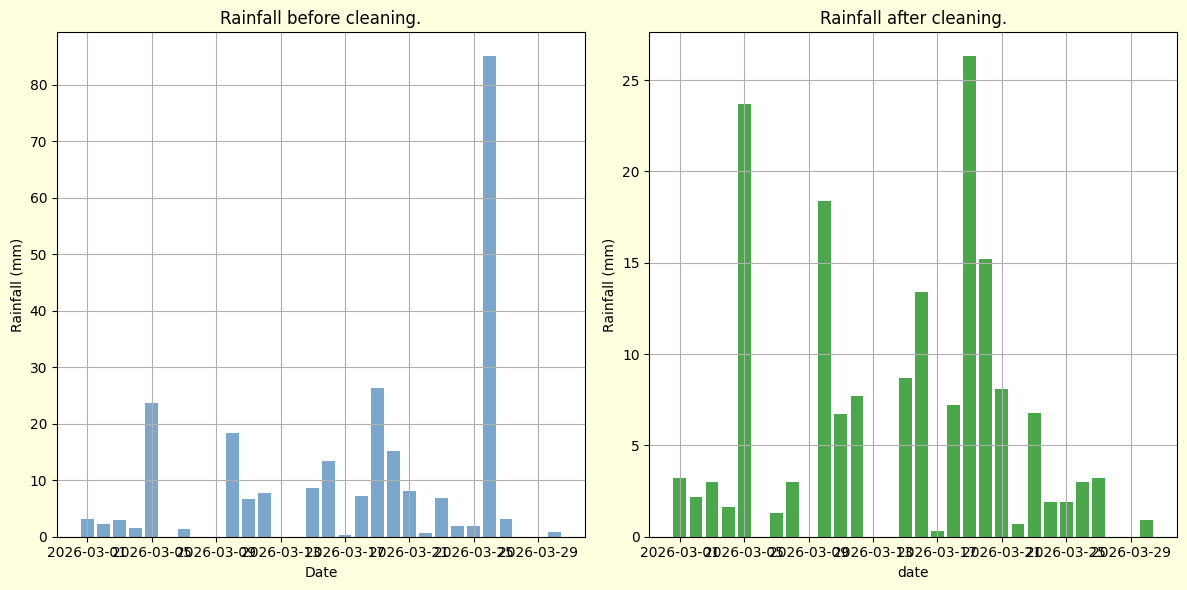

In [12]:
#creating a two sublplots for before and after the cleaning of the weather dataset for rain

plt.figure(figsize=(12,6),facecolor='lightyellow')

#left subplot to show rainfall befor cleaning.
plt.subplot(1,2,1)
plt.bar(weather['date'],weather['rainfall_mm'],color='steelblue',alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.title('Rainfall before cleaning.')
plt.grid(True)

#right subplot to show rainfall after.

plt.subplot(1,2,2)
plt.bar(weather_clean['date'],weather_clean['rainfall_mm'],color='green',alpha=0.7)
plt.title('Rainfall after cleaning.')
plt.xlabel('date')
plt.ylabel('Rainfall (mm)')
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation — Rainfall Before and After Cleaning

The before and after comparison clearly shows the effect of the two
cleaning decisions made on the rainfall column.

In the raw data the extreme value of 85mm on 2026-03-26 dominates the
entire plot, compressing all other values toward zero and making it
impossible to see the natural rainfall variation across the month.
This single outlier was distorting the entire scale of the visualization
and would have similarly distorted any computation that used it.

After cleaning, the rainfall pattern becomes clearly visible. The month
shows a pattern consistent with Kenya's short rains — moderate rainfall
events of 10-26mm scattered across the first three weeks, followed by
a dry spell toward the end of the month. The missing value on day 8 has
been filled with the median of 3.0mm which blends naturally with the
surrounding low rainfall days.

From an irrigation perspective the dry spell visible from day 27 onward
is the most critical observation — with no significant rainfall during
this period the farm is entirely dependent on irrigation to maintain
soil moisture above the stress threshold for all three zones.

### Visualization 2 — Temperature Before and After Cleaning

This plot shows the effect of removing the temperature outlier on day 14
where a reading of 45.8°C was replaced with the column mean of 24.58°C.

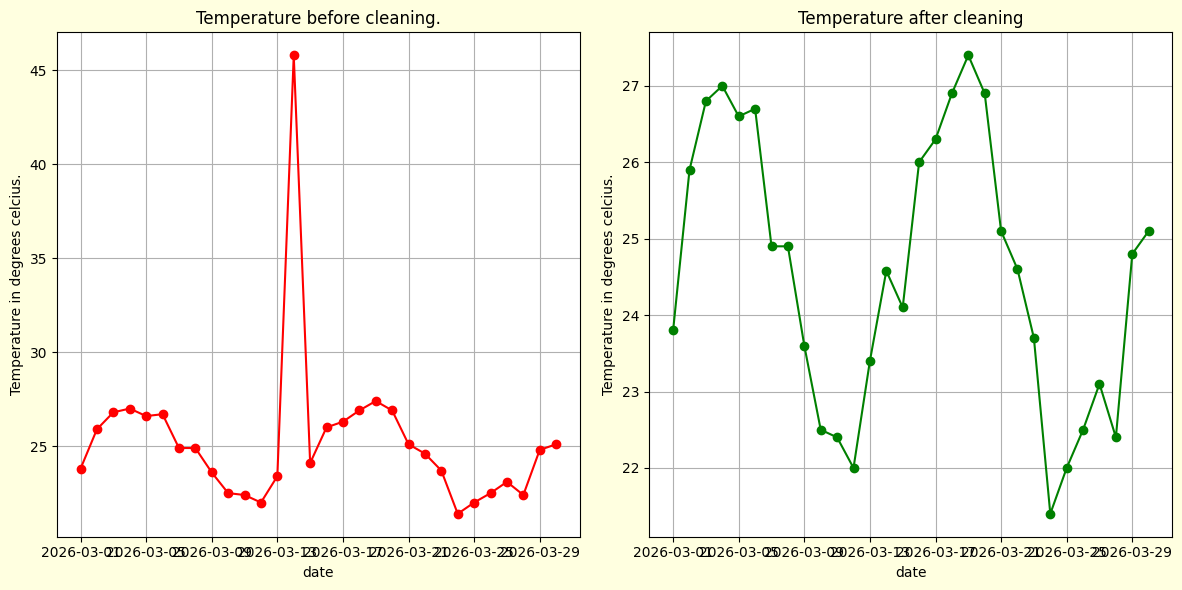

In [13]:
#plots for the before and after temperature

#the whole canvas
plt.figure(figsize=(12,6),facecolor="lightyellow")

#left subplot , temperature before cleaning.
plt.subplot(1,2,1)
plt.plot(weather['date'],weather['temperature_c'],color='red',marker='o')
plt.xlabel('date')
plt.ylabel('Temperature in degrees celcius.')
plt.title('Temperature before cleaning.')
plt.grid(True)

#right subplot.After cleaning
plt.subplot(1,2,2)
plt.plot(weather_clean['date'],weather_clean['temperature_c'],color='green',marker='o')
plt.xlabel('date')
plt.ylabel('Temperature in degrees celcius.')
plt.title('Temperature after cleaning')
plt.grid(True)

plt.tight_layout()
plt.show()


### Interpretation — Temperature Before and After Cleaning

The before plot shows a single extreme spike on day 14 where temperature
was recorded as 45.8°C — a value that is physically impossible for Kenya
in March where temperatures consistently range between 21°C and 27°C.
This spike would have significantly inflated ET estimates for that day,
leading to an overestimation of water loss and an unnecessarily large
irrigation recommendation.

After cleaning the temperature curve shows a smooth and realistic pattern
consistent with the expected seasonal range. Temperatures remain between
21°C and 27°C throughout the month with a slight cooling trend visible
in the middle of the month coinciding with the higher rainfall days, which
is physically consistent — rainfall events are typically accompanied by
cloud cover that reduces solar heating and lowers daytime temperatures.

From an irrigation perspective accurate temperature data is critical
because temperature is one of the four inputs to the ET formula. A
corrupted temperature reading directly corrupts the ET estimate and
cascades into an incorrect water balance calculation and irrigation
recommendation.

### Visualization 3 — Soil Moisture by Zone Over Time

This plot shows how soil moisture evolved across all three zones over
the 30 day period using the cleaned dataset. The minimum moisture
thresholds and target moisture levels for each zone are included as
reference lines to show when each zone was under stress.

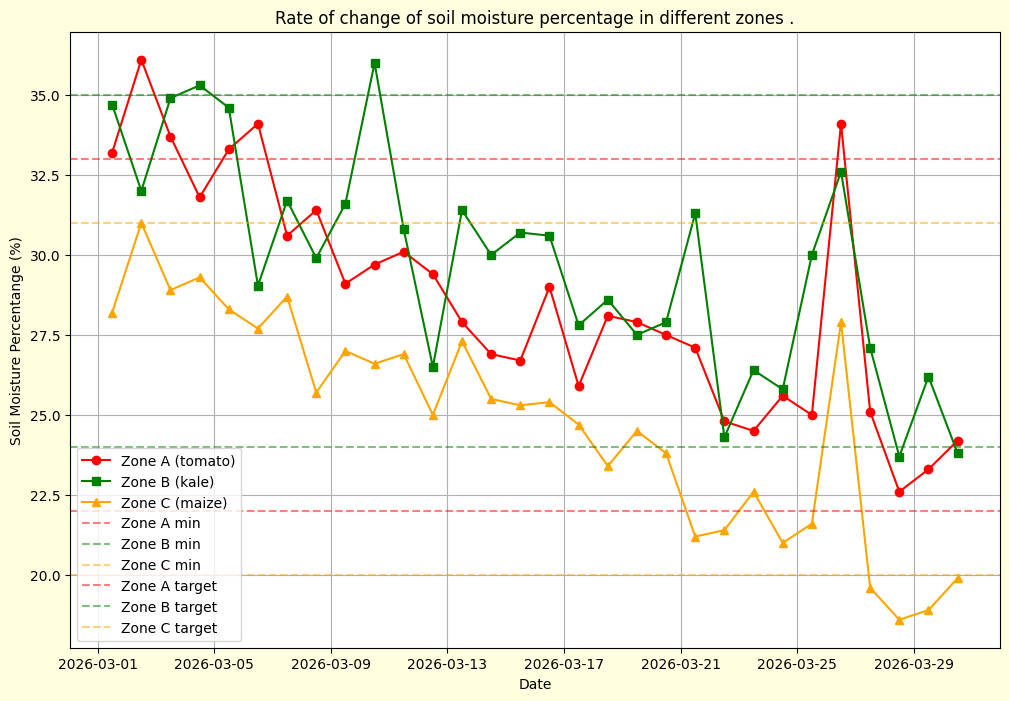

In [20]:
#min_moisture_pct & target_moisture_pct

#first , we extract data from the individual different zones and group them.
zone_a = soil_clean[soil_clean['zone_id'] == 'Zone_A'].reset_index(drop=True)
zone_b = soil_clean[soil_clean['zone_id'] == 'Zone_B'].reset_index(drop=True)
zone_c = soil_clean[soil_clean['zone_id'] == 'Zone_C'].reset_index(drop=True)

#getting the threshholds for the different zones .
    #starting with the lower threshholds , (min_moisture_pct)
min_a = params[params['zone_id'] == 'Zone_A']['min_moisture_pct'].iloc[0]
min_b = params[params['zone_id'] == 'Zone_B']['min_moisture_pct'].iloc[0]
min_c = params[params['zone_id'] == 'Zone_C']['min_moisture_pct'].iloc[0]

    #upper threshholds , ( target_moisture_pct)
target_a = params[params['zone_id'] == 'Zone_A']['target_moisture_pct'].iloc[0]
target_b = params[params['zone_id'] == 'Zone_B']['target_moisture_pct'].iloc[0]
target_c = params[params['zone_id'] == 'Zone_C']['target_moisture_pct'].iloc[0]

#The actual plotting.

#the canvas.(no subplots in this one.)
plt.figure(figsize=(12,8),facecolor='lightyellow')

#plot the lines(that show soil moisture in the different zones)
plt.plot(zone_a['timestamp'],zone_a['soil_moisture_pct'],color='red',marker='o',label='Zone A (tomato)')
plt.plot(zone_b['timestamp'],zone_b['soil_moisture_pct'],color='green',marker='s',label='Zone B (kale)')
plt.plot(zone_c['timestamp'],zone_c['soil_moisture_pct'],color='orange',marker='^',label='Zone C (maize)')


#plotting the minimum threshholds using (axhline) axis  horizontal line
plt.axhline(min_a,linestyle='--',color='red',label='Zone A min',alpha=0.5)
plt.axhline(min_b,linestyle='--',color='green',label='Zone B min',alpha=0.5)
plt.axhline(min_c,linestyle='--',color='orange',label='Zone C min',alpha=0.5)

#plotting the maximum threshholds ( target moisture pct)

plt.axhline(target_a,color='red',linestyle='--',label='Zone A target',alpha=0.5)
plt.axhline(target_b,color='green',linestyle='--',label='Zone B target',alpha=0.5)
plt.axhline(target_c,color='orange',linestyle='--',label='Zone C target',alpha=0.5)


plt.xlabel('Date')
plt.ylabel('Soil Moisture Percentange (%)')
plt.title('Rate of change of soil moisture percentage in different zones .')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation — Soil Moisture by Zone Over Time

The plot reveals a clear and consistent declining trend across all three
zones over the 30 day period, with a brief recovery around day 26
corresponding to the significant rainfall event visible in the cleaned
rainfall data.

Zone B consistently maintains the highest soil moisture throughout the
period, which is consistent with its lower drainage coefficient of 0.15
meaning it retains water more effectively than the other zones. Zone C
consistently records the lowest moisture levels reflecting its higher
drainage coefficient of 0.22 and the largest area of 180m² which
requires more water to maintain adequate moisture levels.

The most critical observation is that all three zones approach or breach
their minimum moisture thresholds toward the end of the month. Zone C
drops closest to its minimum threshold of 20% reaching values as low as
18.6% on day 28, indicating the maize crop was experiencing moisture
stress during this period. Zone A and Zone B also show declining trends
that suggest irrigation intervention was urgently needed from around
day 20 onward.

The brief recovery on day 26 across all zones confirms that the rainfall
event on that day provided temporary relief, but the subsequent return
to declining moisture levels shows that rainfall alone was insufficient
to maintain adequate moisture and that supplementary irrigation was
necessary.

### Visualization 4 — Water Deficit by Zone Over Time

This plot shows the daily water deficit for each zone — the gap between
the target moisture and the actual soil moisture on each day. A larger
deficit means the zone is further from its target and requires more
urgent irrigation attention.

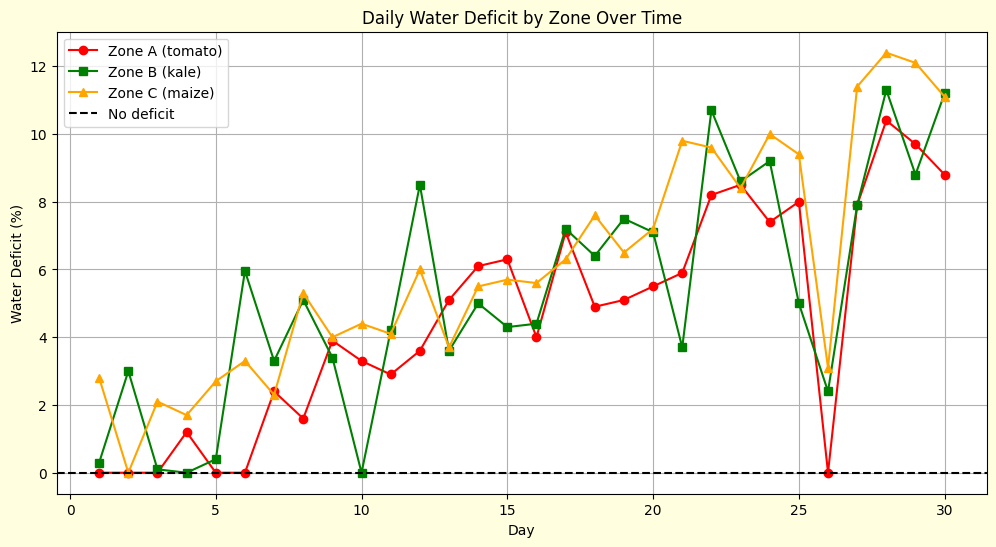

In [23]:
# calculate daily water deficit for each zone
days = list(range(1, 31))

deficit_a = []
deficit_b = []
deficit_c = []

for i in range(30):
    deficit_a.append(max(0, target_a - zone_a['soil_moisture_pct'].iloc[i]))
    deficit_b.append(max(0, target_b - zone_b['soil_moisture_pct'].iloc[i]))
    deficit_c.append(max(0, target_c - zone_c['soil_moisture_pct'].iloc[i]))

plt.figure(figsize=(12, 6), facecolor='lightyellow')

plt.plot(days, deficit_a, color='red',   marker='o', label='Zone A (tomato)')
plt.plot(days, deficit_b, color='green',  marker='s', label='Zone B (kale)')
plt.plot(days, deficit_c, color='orange', marker='^', label='Zone C (maize)')
plt.axhline(y=0, color='black', linestyle='--', label='No deficit')

plt.title('Daily Water Deficit by Zone Over Time')
plt.xlabel('Day')
plt.ylabel('Water Deficit (%)')
plt.legend()
plt.grid(True)
plt.show()

### Interpretation — Water Deficit by Zone Over Time

The water deficit plot provides a direct measure of irrigation urgency
for each zone on each day. A value of zero means the zone has met or
exceeded its target moisture and no irrigation is needed. A positive
value means the zone is below target and irrigation is required.

All three zones show a generally increasing deficit trend over the
30 day period, confirming the declining soil moisture pattern observed
in Visualization 3. Zone C consistently records the largest deficits
throughout the month, reaching a peak of approximately 12.4% on day 28.
This means the maize crop in Zone C was 12.4 percentage points below
its target moisture on that day — a severe deficit that would have
caused significant crop stress and yield reduction if left unaddressed.

Zone B shows the smallest deficits overall, consistent with its higher
water retention capacity. However even Zone B shows increasing deficits
toward the end of the month, suggesting that no zone was receiving
adequate irrigation during this period.

The brief drop in deficits around day 26 across all zones corresponds
to the rainfall event visible in the rainfall visualization, confirming
that rainfall temporarily restored moisture levels before the deficit
resumed its upward trend.

From an irrigation planning perspective this plot clearly identifies
Zone C as the highest priority zone requiring the most frequent and
largest irrigation applications, followed by Zone A and then Zone B.

### Visualization 5 — Pump Flow by Zone Over Time

This plot shows the pump flow rate for each zone over the 30 day period.
It helps identify the sensor fault on Zone B day 21 where pump flow was
recorded as 0.0 lpm despite the pump being operational, and shows how
the cleaned data compares to the raw data.

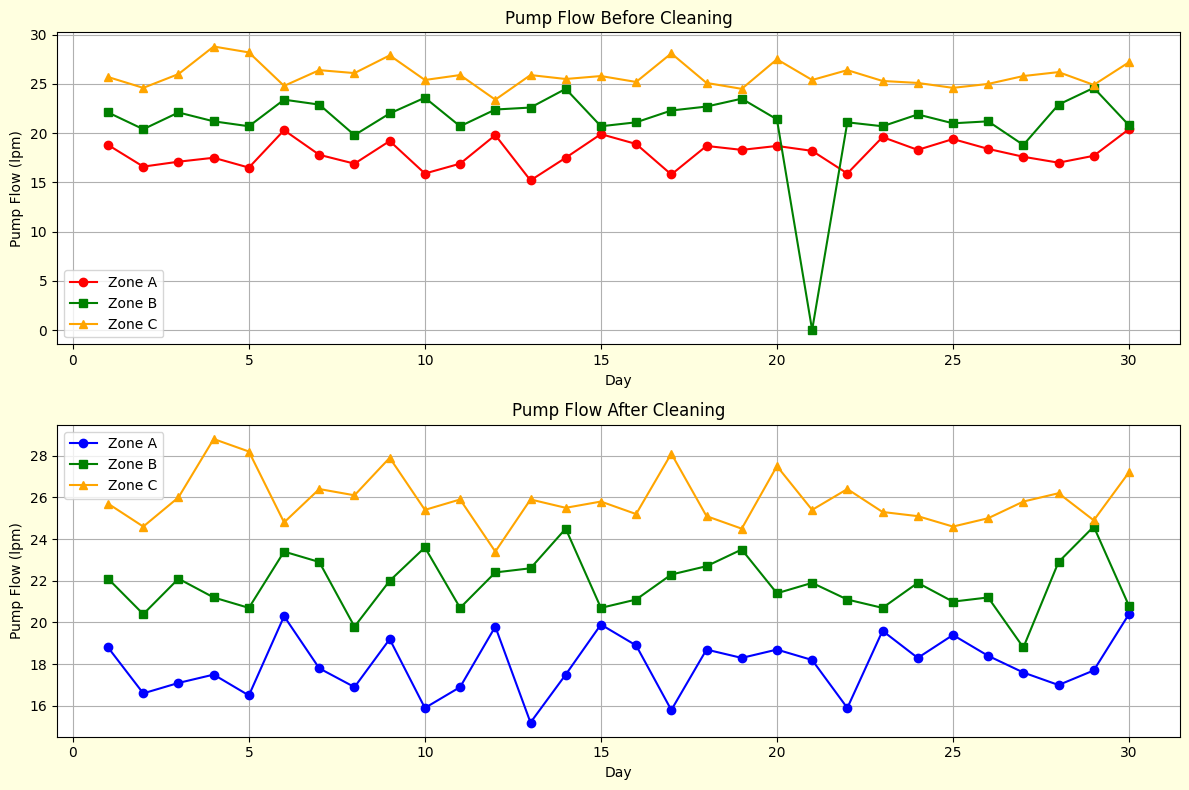

In [25]:
# extract pump flow before and after cleaning
pump_a_raw   = soil[soil['zone_id'] == 'Zone_A'].reset_index(drop=True)['pump_flow_lpm']
pump_b_raw   = soil[soil['zone_id'] == 'Zone_B'].reset_index(drop=True)['pump_flow_lpm']
pump_c_raw   = soil[soil['zone_id'] == 'Zone_C'].reset_index(drop=True)['pump_flow_lpm']

pump_a_clean = zone_a['pump_flow_lpm']
pump_b_clean = zone_b['pump_flow_lpm']
pump_c_clean = zone_c['pump_flow_lpm']

plt.figure(figsize=(12, 8), facecolor='lightyellow')

# before cleaning
plt.subplot(2, 1, 1)
plt.plot(days, pump_a_raw, color='red',   marker='o', label='Zone A')
plt.plot(days, pump_b_raw, color='green',  marker='s', label='Zone B')
plt.plot(days, pump_c_raw, color='orange', marker='^', label='Zone C')
plt.title('Pump Flow Before Cleaning')
plt.xlabel('Day')
plt.ylabel('Pump Flow (lpm)')
plt.legend()
plt.grid(True)

# after cleaning
plt.subplot(2, 1, 2)
plt.plot(days, pump_a_clean, color='blue',   marker='o', label='Zone A')
plt.plot(days, pump_b_clean, color='green',  marker='s', label='Zone B')
plt.plot(days, pump_c_clean, color='orange', marker='^', label='Zone C')
plt.title('Pump Flow After Cleaning')
plt.xlabel('Day')
plt.ylabel('Pump Flow (lpm)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpretation — Pump Flow by Zone Over Time

The pump flow plot reveals the operational pattern of the irrigation
system across all three zones and clearly shows the effect of the
sensor fault on Zone B day 21.

In the raw data a sharp drop to 0.0 lpm is visible on day 21 for
Zone B. This reading was accompanied by a CHECK sensor status flag
confirming it was a fault rather than a genuine pump shutdown. A
pump flow of zero while the zone is below its target moisture would
suggest no irrigation was being applied, which would be an alarming
and incorrect signal to a farm manager relying on this data.

After cleaning the Zone B pump flow on day 21 is replaced with the
zone median, restoring a realistic value consistent with surrounding
days and removing the misleading signal.

Looking at the overall pump flow pattern Zone C consistently records
the highest pump flow rates throughout the month, which is consistent
with its largest area of 180m² and highest drainage coefficient of
0.22 — it requires more water to be pumped to maintain adequate
moisture levels. Zone A records the lowest pump flow rates reflecting
its smaller area and moderate drainage coefficient.

The generally stable pump flow rates across all zones throughout the
month suggest the irrigation system was operating consistently, with
the exception of the Zone B day 21 fault. However the increasing
water deficits seen in Visualization 4 despite consistent pumping
suggests that the pump flow rates were insufficient to keep up with
the evapotranspiration losses and declining moisture levels,
particularly toward the end of the month.

### Task 6 : Merging the cleaned datasets 

In [28]:
# convert both date columns to the same string format
soil_clean['date']    = pd.to_datetime(soil_clean['timestamp']).dt.strftime('%Y-%m-%d')
weather_clean['date'] = pd.to_datetime(weather_clean['date']).dt.strftime('%Y-%m-%d')

# merge all three datasets
merged = soil_clean.merge(weather_clean, on='date', how='left')
merged = merged.merge(params, on='zone_id', how='left')

# check for nulls introduced by merging
print("Nulls after merging:")
print(merged.isnull().sum())

# save to processed folder
merged.to_csv("../data/processed/cleaned_irrigation_dataset.csv", index=False)
print("\nCleaned dataset saved successfully.")
print("Shape:", merged.shape)

Nulls after merging:
timestamp               0
zone_id                 0
soil_moisture_pct       0
tank_level_liters       0
pump_flow_lpm           0
pump_power_watts        0
sensor_status           0
date                    0
rainfall_mm             0
temperature_c           0
humidity_pct            0
wind_speed_mps          0
solar_index             0
crop_type               0
area_m2                 0
min_moisture_pct        0
target_moisture_pct     0
field_capacity_pct      0
drainage_coefficient    0
dtype: int64

Cleaned dataset saved successfully.
Shape: (90, 19)


In [29]:
#checking out the structure of the merged dataset.
print("\n Merged Dataset : \n")
print(merged.info(),"\n")
print(merged.head(),"\n")
print(merged.describe(),"\n")




 Merged Dataset : 

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   timestamp             90 non-null     datetime64[us]
 1   zone_id               90 non-null     str           
 2   soil_moisture_pct     90 non-null     float64       
 3   tank_level_liters     90 non-null     int64         
 4   pump_flow_lpm         90 non-null     float64       
 5   pump_power_watts      90 non-null     int64         
 6   sensor_status         90 non-null     str           
 7   date                  90 non-null     str           
 8   rainfall_mm           90 non-null     float64       
 9   temperature_c         90 non-null     float64       
 10  humidity_pct          90 non-null     float64       
 11  wind_speed_mps        90 non-null     float64       
 12  solar_index           90 non-null     float64       
 13  crop_type   